In [1]:
# Another try at numerically solving the advection diffusion equation
# It seems we can just use Dirichlet boundary condition
import xarray as xr
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import itertools as it
from tqdm import tqdm

zsoii = np.array([0, 0.0175, 0.0451, 0.0906, 0.1655, 0.2891, 0.4929, 0.8289, 
                1.3828, 2.2961, 3.8019])
zsoi = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607])
"""
zsoii = np.linspace(0, 1, 11)
zsoi = np.convolve(zsoii, [0.5,0.5], mode = 'valid')
"""
dz = np.diff(zsoii)

# number of soil layers
nlevsoi = 10

In [2]:
def a_step(c_prev, q_int, theta, watsat, sourcesink, d0, dt, euler):
    """
    c_prev - start concentration (mol/kg)
    q_int - water flux at grid boundaries (m/s)
    theta - soil moisture value (m3/m3)
    watsat - porosity
    sourcesink - source/sink strength (mol/kg/s)
    d0 - diffusion coefficient in water (m2/s)
    dt - time step size (s)
    """

    ## it doesn't matter if I multiply in here or outside
    #q_int = q_int * dt
    #sourcesink = sourcesink * dt
    #d0 = d0 * dt

    # convert Darcy velocity at interfaces to grid centers
    q = q_int[1:]*(zsoi-zsoii[:-1])/dz + q_int[:-1]*(zsoii[1:]-zsoi)/dz
    ## (double check the weights are correct)
    ## plt.plot(zsoii, q_int, '-o')
    ##plt.plot(zsoi, q, '-x')

    # the distance between nodes (center of grids)
    dx = np.diff(zsoi)

    # pad half grids at the top and at the bottom
    dx = np.append(np.insert(zsoi, 0, dz[0]), dz[-1])

    # pad half grids to keep indexing consistent with dx
    c_prev = np.append(np.insert(c_prev, 0, 0), 0)
    q = np.append(np.insert(q, 0, 0), 0)
    theta = np.append(np.insert(theta, 0, 0.6), 0.6)
    watsat = np.append(np.insert(watsat, 0, 0.6), 0.6)
    sourcesink = np.append(np.insert(sourcesink, 0, 0), 0)

    # calculate the layerwise effective diffusion coefficient
    Deff = d0 * theta**(10/3) / watsat**2

    # assemble the matrix: dx/dt = Ax, for use in ODE integration
    A = np.zeros([nlevsoi+2, nlevsoi+2])
    for i in range(1, nlevsoi+1):
        # Deff * d^2 C / dx^2
        A[i,i-1] = Deff[i] * 2 / (dx[i]*(dx[i] + dx[i+1]))
        A[i,i] = - Deff[i] * 2 / (dx[i]*dx[i+1])
        A[i,i+1] = Deff[i] * 2 / (dx[i+1]*(dx[i] + dx[i+1]))

        # calculate d Deff / dx
        dDeff = - dx[i+1] / (dx[i]*(dx[i] + dx[i+1])) * Deff[i-1] + \
                (dx[i+1]-dx[i]) / (dx[i]*dx[i+1]) * Deff[i] + \
                dx[i] / (dx[i+1]*(dx[i] + dx[i+1])) * Deff[i+1]

        # Add (d Deff / dx - q) * dC / dx
        A[i,i-1] = A[i,i-1] + (dDeff - q[i]) * (-dx[i+1] / (dx[i]*(dx[i] + dx[i+1])))
        A[i,i] = A[i,i] + (dDeff - q[i]) * (dx[i+1] - dx[i]) / (dx[i]*dx[i+1])
        A[i,i+1] = A[i,i+1] + (dDeff - q[i]) * dx[i] / (dx[i+1]*(dx[i]+dx[i+1]))


    if euler == 'forward':
        # Use forward Euler integration

        # calculate \theta * dx/dt
        dcdt = np.matmul(A, c_prev) / theta + sourcesink / theta

        c_next = dcdt * dt + c_prev

        #print(dcdt)
        #print(c_next)

        # force positive
        c_next = np.maximum(c_next, 0)

        # This made things worse
        ## re-scale to insure mass balance
        tot = sum(c_next)
        c_next = c_next * tot / sum(c_next)

    else:
        # use backward Euler integration

        # \theta * (C_{i+1} - C_{i}) / dt = A C_{i+1} + R
        # which simplifies to
        # (diag(\theta)-A*dt) * C_{i+1} = \theta*C_i + R*dt
        A_rev = np.diag(theta) - A*dt
        B = theta*c_prev + sourcesink * dt
        c_next = np.linalg.solve(A_rev, B)

    return c_next[1:nlevsoi+1]
    # return dcdt[1:nlevsoi+1]

In [3]:
# initial concentration (mol kg-1 water)
c0 = np.zeros(nlevsoi)

# porosity
watsat = np.ones(nlevsoi)*0.6 # hr['watsat'][:, :nlevsoi, 0].values 

# water diffusion coefficient: m2/s
d0 = 7.93e-10 # Ca2+

# constant source strength: mol L-1 (soil volume) s-1
sourcesink = np.zeros(nlevsoi)
sourcesink[0] = 1e-5

6it [01:00, 10.13s/it]


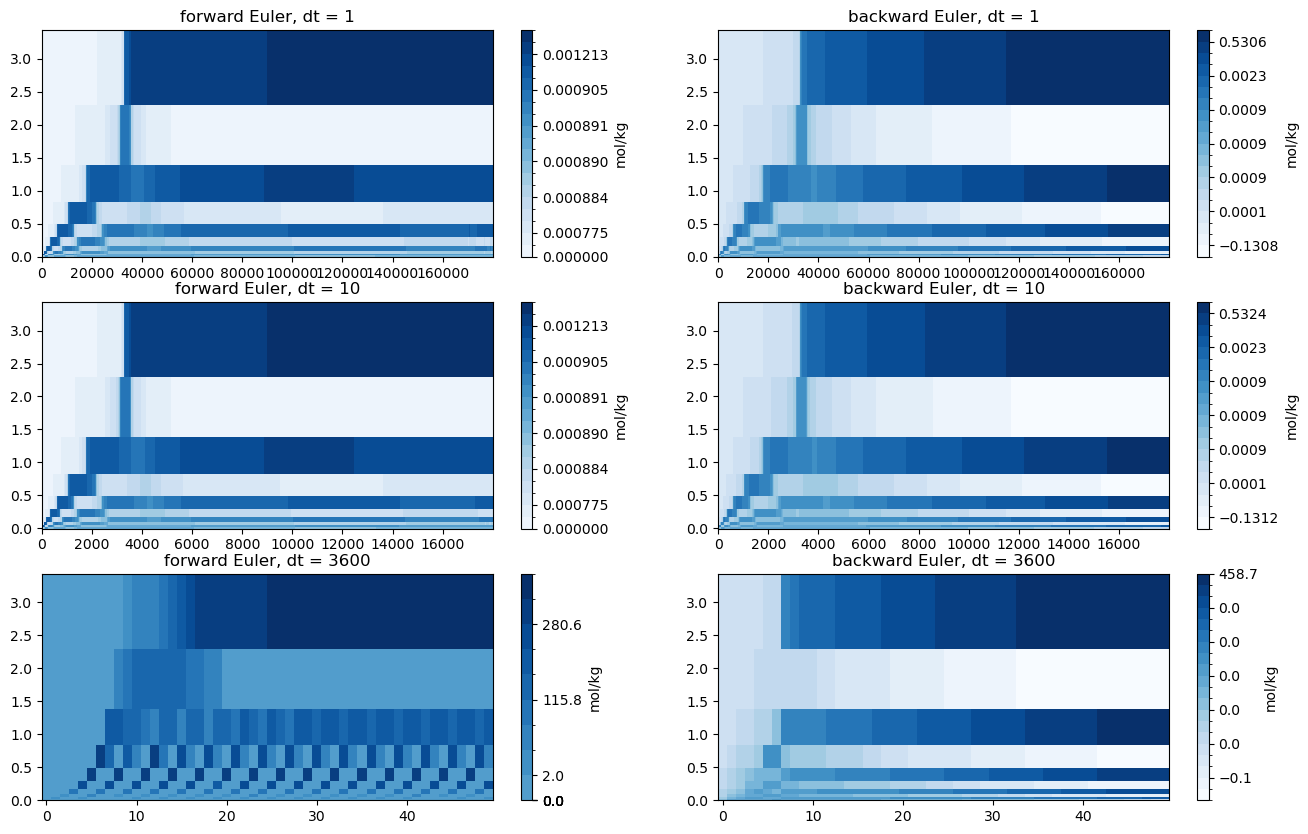

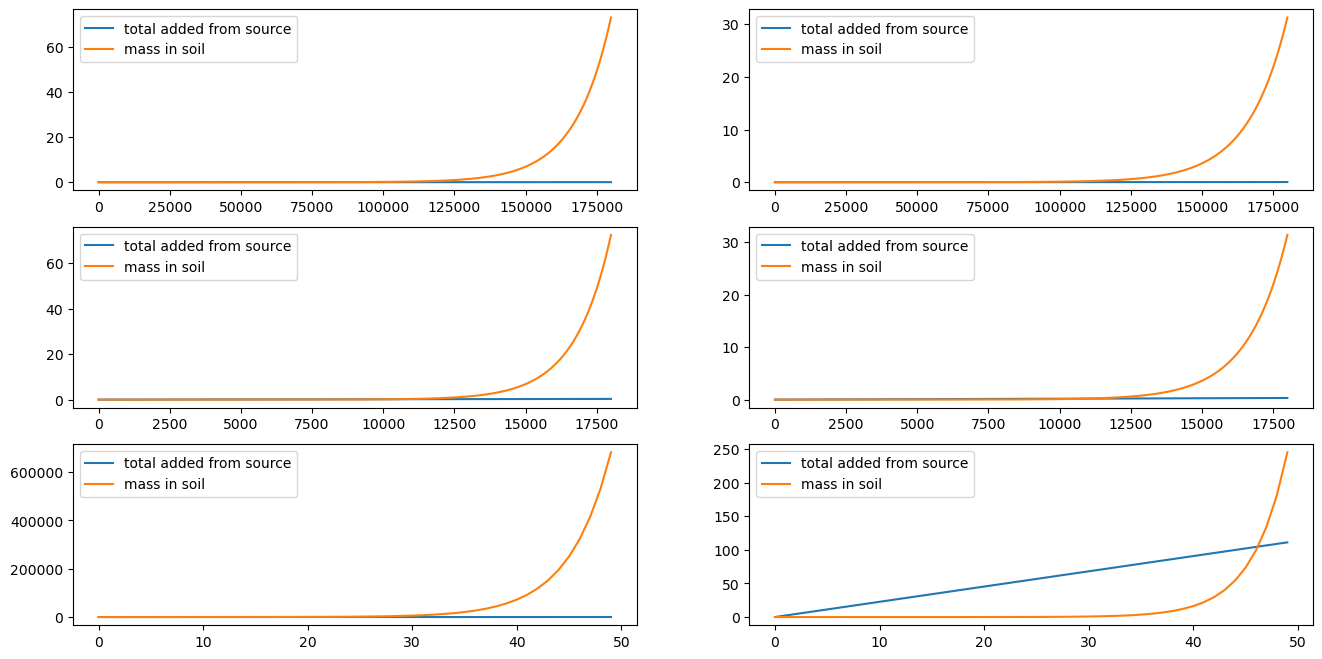

In [4]:
# constant flow rate (m/s)
q_int = np.ones(nlevsoi+1) * 1e-4

# constant soil moisture
h2osoi = np.ones(nlevsoi) * 0.4

# size of time step
length = 3600*50
result_all = {}
for dt, euler in tqdm(it.product([1, 10, 3600], ['forward','backward'])):
        c_prev = c0
        result = np.full([length//dt, nlevsoi], np.nan)
        for t in range(length//dt):
            result[t, :] = a_step(c_prev, q_int, h2osoi, watsat, sourcesink, d0, dt,
                                  euler) # q_int[t,:], h2osoi[t,:]
            c_prev = result[t, :]

        result_all[(dt,euler)] = result

fig, axes = plt.subplots(3, 2, figsize = (16, 10))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward'])):
    ax = axes.flat[i]
    result = result_all[(dt,euler)]
    cf = ax.pcolormesh(np.arange(length//dt), zsoi, result.T, 
                        norm = BoundaryNorm(np.percentile(result.reshape(-1), np.arange(0,101,5)), 
                                            ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, label = 'mol/kg')
    ax.set_title(f'{euler} Euler, dt = {dt}')
plt.savefig('test_main2.png')

# Add the diagnostis of how much source is added v.s. how much remains in the soil column
# mol/kg * m3/m3 * dz, cumsum
fig, axes = plt.subplots(3, 2, figsize = (16, 8))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward'])):
    ax = axes.flat[i]

    result = result_all[(dt,euler)]
    tot_in = np.sum(result * h2osoi * dz, axis = 1)

    total_added = np.arange(0, 3600*50, dt) * np.sum(sourcesink * dz * dt)

    ax.plot(total_added)
    ax.plot(tot_in)
    ax.legend(['total added from source', 'mass in soil'])

0it [00:00, ?it/s]

6it [01:05, 10.87s/it]


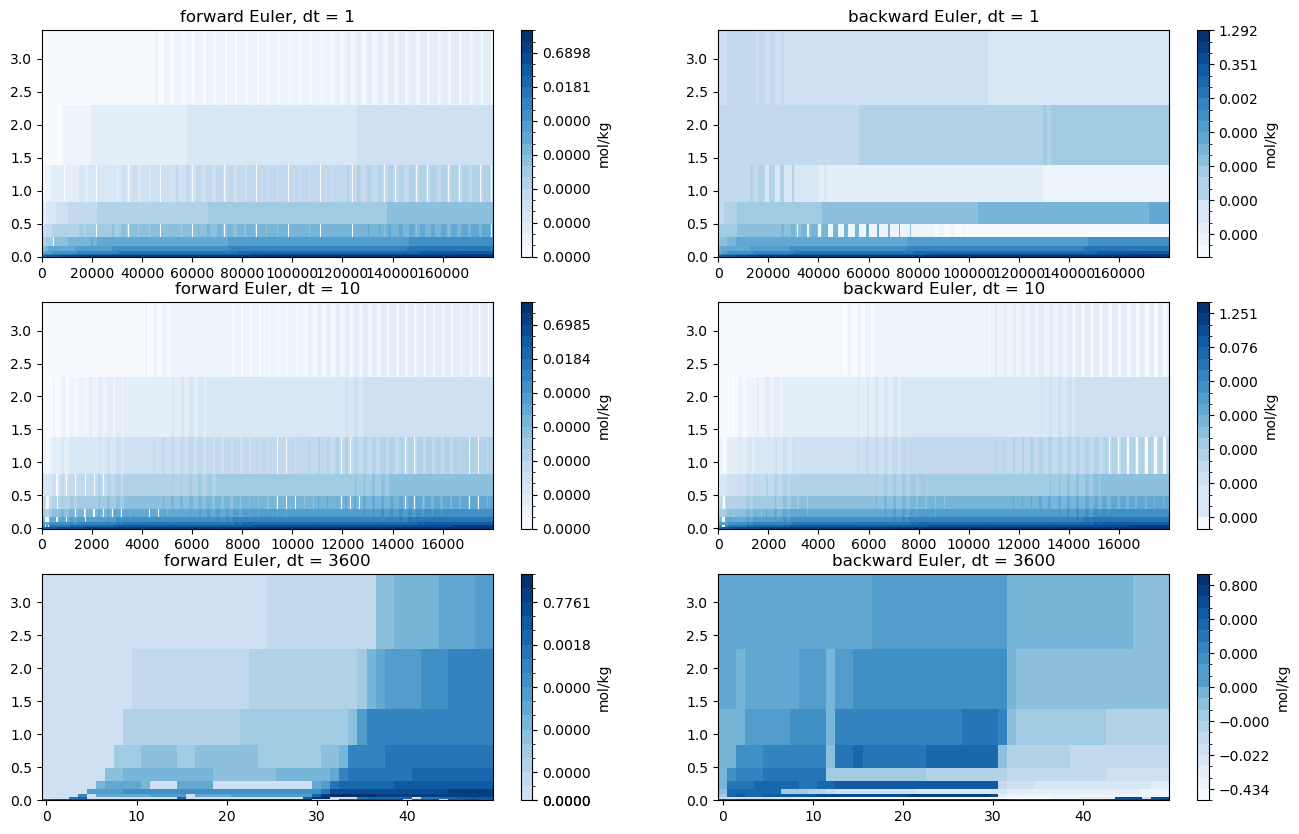

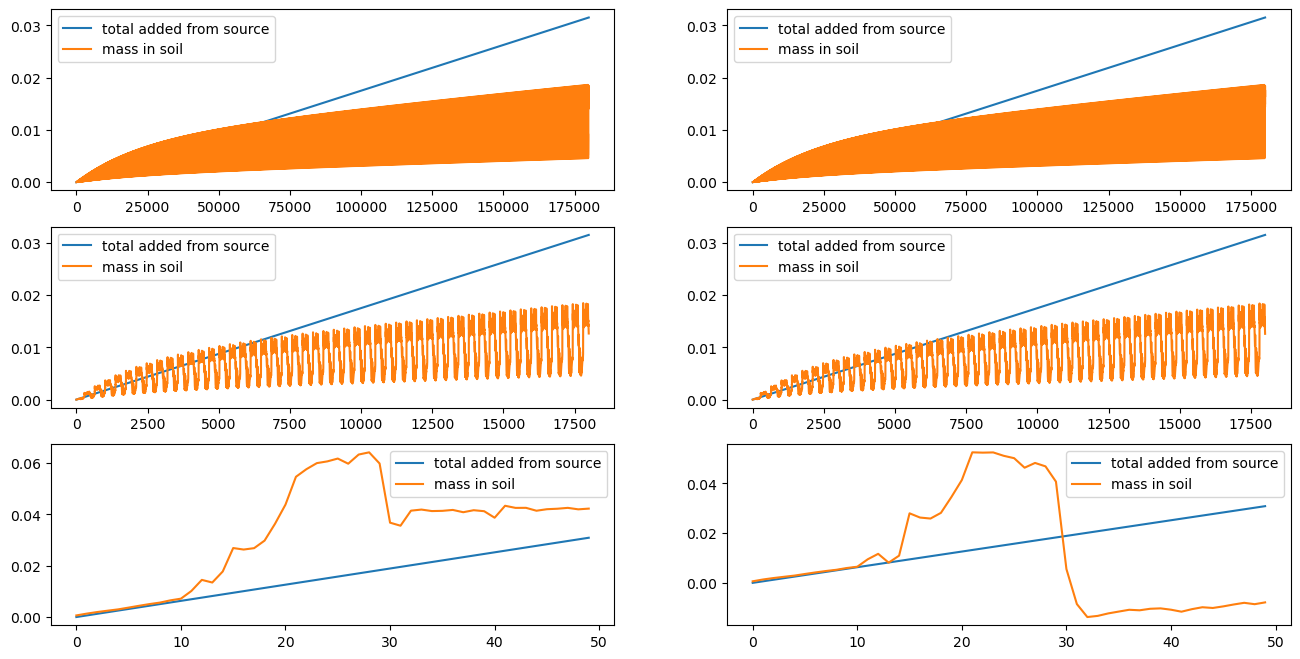

In [5]:
# realistic flow rate and soil moisture
hr = xr.open_dataset(os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw', 'run', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw.elm.h1.1947-01-01-00000.nc'))
q_int = hr['QIN'][:, :(nlevsoi+1), 0].values * 1e-3 * 24 # mm/s => m/s, account for daily averaging
h2osoi = hr['H2OSOI'][:, :nlevsoi, 0].values # m3/m3 soil moisture
hr.close()

# size of time step
length = 3600*50
result_all = {}
h2o_all = {}
for dt, euler in tqdm(it.product([1, 10, 3600], ['forward','backward'])):
        c_prev = c0
        result = np.full([length//dt, nlevsoi], np.nan)
        h2osoi_record = np.full([length//dt, nlevsoi], np.nan)

        for t in range(length//dt):
            result[t, :] = a_step(c_prev, 
                                  q_int[np.mod(t, len(q_int)),:], # repeat the same cycle
                                  h2osoi[np.mod(t, len(q_int)),:], # repeat the same cycle
                                  watsat, sourcesink, d0, dt,
                                  euler)
            c_prev = result[t, :]

            h2osoi_record[t, :] = h2osoi[np.mod(t, len(q_int)),:]

        result_all[(dt,euler)] = result
        h2o_all[(dt,euler)] = h2osoi_record

fig, axes = plt.subplots(3, 2, figsize = (16, 10))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward'])):
    ax = axes.flat[i]
    result = result_all[(dt,euler)]
    cf = ax.pcolormesh(np.arange(length//dt), zsoi, result.T, 
                        norm = BoundaryNorm(np.percentile(result.reshape(-1), np.arange(0,101,5)), 
                                            ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, label = 'mol/kg')
    ax.set_title(f'{euler} Euler, dt = {dt}')
plt.savefig('test_main2_2.png')

# Add the diagnostis of how much source is added v.s. how much remains in the soil column
# mol/kg * m3/m3 * dz, cumsum
fig, axes = plt.subplots(3, 2, figsize = (16, 8))
for i,(dt,euler) in enumerate(it.product([1, 10, 3600], ['forward','backward'])):
    ax = axes.flat[i]

    result = result_all[(dt,euler)]
    tot_in = np.sum(result * h2o_all[(dt,euler)] * dz, axis = 1)

    total_added = np.arange(0, len(tot_in)) * np.sum(sourcesink * dz * dt)

    ax.plot(total_added)
    ax.plot(tot_in)
    ax.legend(['total added from source', 'mass in soil'])

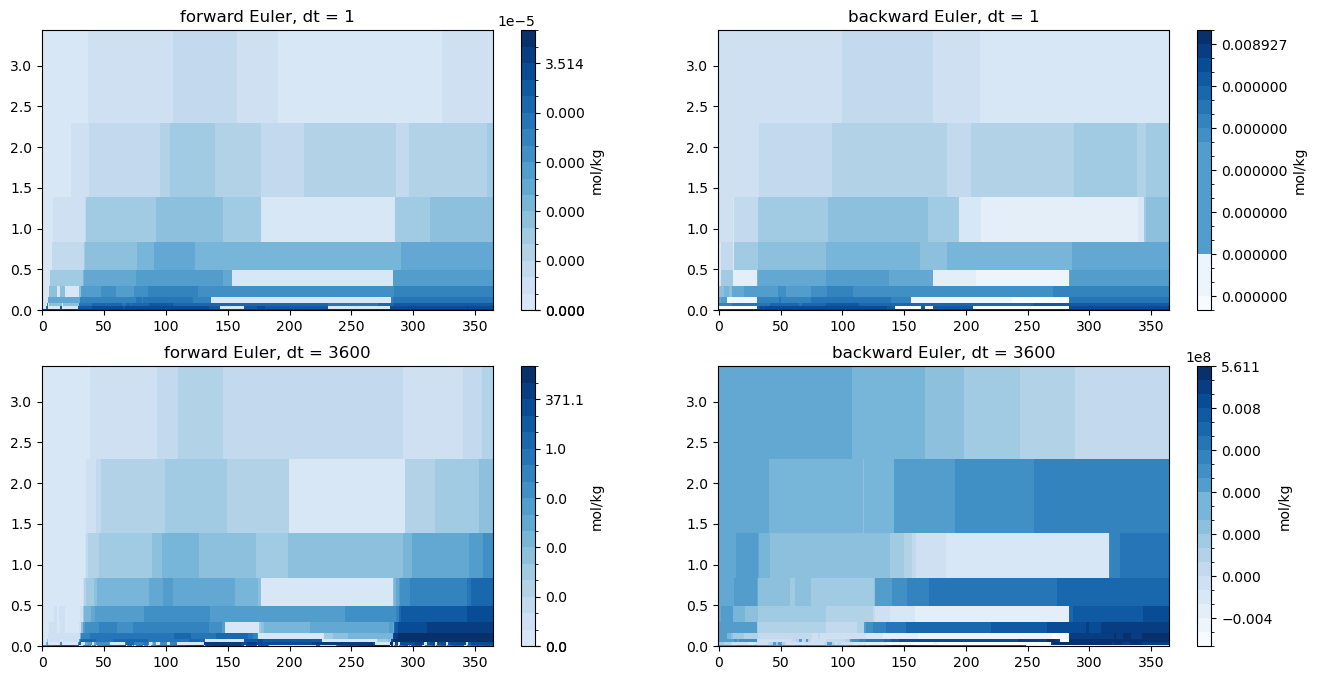

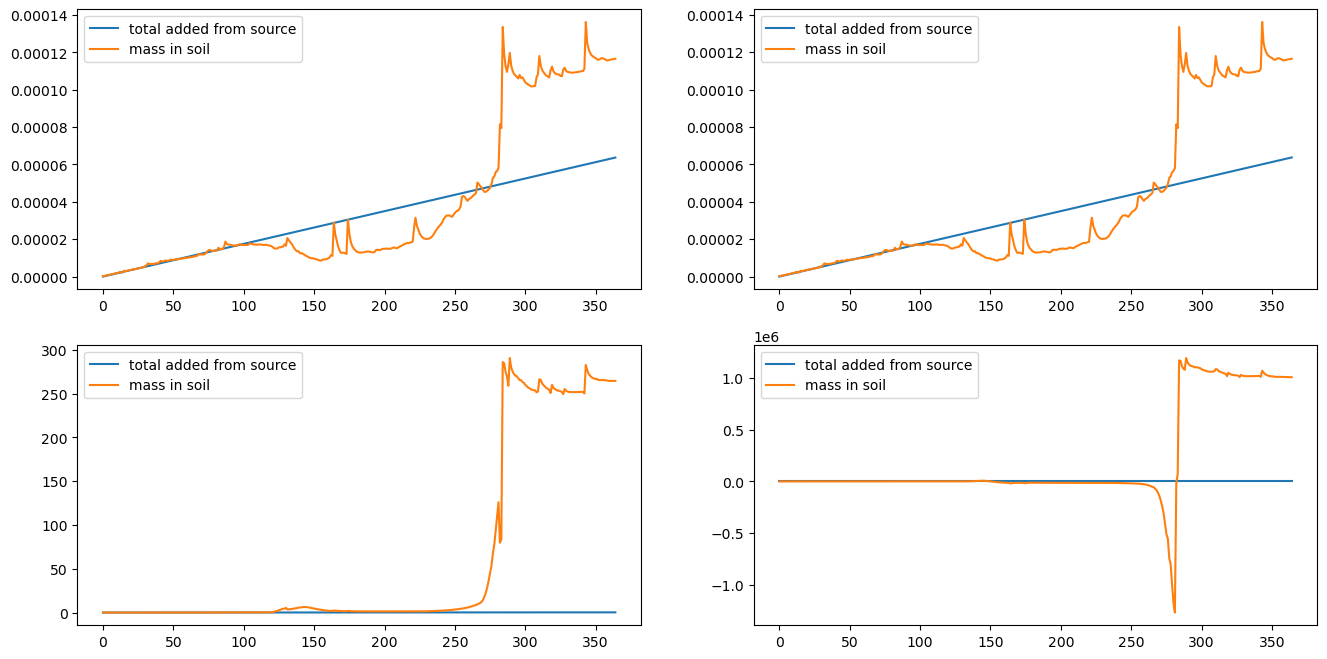

In [6]:
# non-cyclic, same forcing
hr = xr.open_dataset(os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw', 'run', 
                                  '20250323_UC_Davis_ICB20TRCNPRDCTCBC_3year_rmethod1erw.elm.h1.1947-01-01-00000.nc'))
q_int = hr['QIN'][:, :(nlevsoi+1), 0].values * 1e-3 * 24 # mm/s => m/s, account for daily averaging
h2osoi = hr['H2OSOI'][:, :nlevsoi, 0].values # m3/m3 soil moisture
hr.close()


result_all = {}
for dt in [1,3600]:
    for euler in ['forward','backward']:

        c_prev = c0
        result = np.full([365, nlevsoi], np.nan)
        for t in range(365):
            result[t, :] = a_step(c_prev, q_int[t,:], h2osoi[t,:], watsat, sourcesink, d0, dt,
                                  euler)
            c_prev = result[t, :]

        result_all[(dt,euler)] = result

fig, axes = plt.subplots(2, 2, figsize = (16, 8))
for i,(dt,euler) in enumerate(it.product([1,3600], ['forward','backward'])):
    ax = axes.flat[i]
    result = result_all[(dt,euler)]
    cf = ax.pcolormesh(np.arange(365), zsoi, result.T, 
                        norm = BoundaryNorm(np.percentile(result.reshape(-1), np.arange(0,101,5)), 
                                            ncolors = 256), cmap = 'Blues')
    plt.colorbar(cf, ax = ax, label = 'mol/kg')
    ax.set_title(f'{euler} Euler, dt = {dt}')
plt.savefig('test_main3.png')

# Add the diagnostis of how much source is added v.s. how much remains in the soil column
# mol/kg * m3/m3 * dz, cumsum
fig, axes = plt.subplots(2, 2, figsize = (16, 8))
for i,(dt,euler) in enumerate(it.product([1,3600], ['forward','backward'])):
    ax = axes.flat[i]

    result = result_all[(dt,euler)]
    tot_in = np.sum(result * h2osoi * dz, axis = 1)

    total_added = np.arange(0, 365) * np.sum(sourcesink * dz * dt)

    ax.plot(total_added)
    ax.plot(tot_in)
    ax.legend(['total added from source', 'mass in soil'])